### <div style="text-align: center;" markdown="1"> ADRL Assignment 1 </div>
#### <div style="text-align: center;" markdown="1"> Team: Shivam Padmani, Saurav Rajan Saraf </div>


We have performed various experiments with training of GANs. \
Our experiments are listed as below: 
| Experiment # | Question # | Model Type          | Dataset Description                     | Key Parameters (e.g., Batch Size, Learning Rate) | Results (e.g., FID Score, Epochs) | Notes/Observations                              |
|--------------|------------|---------------------|------------------------------------------|-------------------------------------------------|----------------------------------|------------------------------------------------|
| 1            | Q2    | CNN Based Classifier              |Butterfly Images, 75 classes | Batch Size: 64, Learning Rate: 0.0002            | Accuracy:      | Classification accuracy    |


| Feature Size | Epochs | Accuracy  |
|--------------|--------|-----------|
| 64           | 10     | 23.23%    |
| 256          | 10     | 66.69%    |
| 256          | 50     | 74.31%    |
| 512          | 50     | 76.07%    |
| 512          | 200     | 73.15%   |
| 1024          | 100     | 72.38%   |

In [1]:
import os
import tqdm
import random
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

Using device:  cuda


In [2]:
# Calculate mean and standard deviation from the given data
def mean_std(dataset):
    mean = 0.0
    std = 0.0
    num_samples = 0
    for (
        images,
        _,
    ) in dataset:  # _ is labels of images from 0 to 89 assigned to each number
        images = images.to(device)
        batch_samples = images.size(0)  # no of images in one batch
        images = images.view(
            batch_samples, images.size(1), -1
        )  # Reshape to (batch size, 3 (RGB), H*W)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        num_samples += batch_samples
    print("Number of Images: ", num_samples)
    return mean / num_samples, std / num_samples

##### Load data


In [3]:
path = os.path.join(os.getcwd(), "data", "butterfly")
image_width = 128
image_height = 128
batch_size = 128
num_workers = 8
transform1 = transforms.Compose([transforms.Resize((image_height,image_width)),transforms.ToTensor()])
train_data = datasets.ImageFolder(root = path, transform = transform1)
train_loader = DataLoader(train_data,batch_size=batch_size)
val_dataloader = DataLoader(train_data,batch_size=batch_size)
# mean, std = mean_std(train_loader)
mean = torch.tensor([0.47998455, 0.46537864, 0.33653912]) # After Calculation, Mean is directly given to the code.
std = torch.tensor([0.22608626, 0.22103393, 0.21348171])
transform = transforms.Compose(
    [
        transforms.Resize((image_height, image_width)),
        transforms.CenterCrop((image_height, image_width)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]
)
dataset = datasets.ImageFolder(root=path, transform=transform)

train_size = int(0.7 * len(dataset))
val_size =int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset,test_size = torch.utils.data.random_split(dataset,[train_size,val_size,test_size])
train_dataloader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers
)
val_dataloader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers
)
test_dataloader = DataLoader(
    test_size, batch_size=batch_size, shuffle=True, num_workers=num_workers
)
classes = dataset.classes
print(classes)
# We are not spliting train and test data like conventional machine learning for calculating accuracy.
print("Mean: ", mean.cpu().numpy(), "Std dev: ", std.cpu().numpy())

['ADONIS', 'AFRICAN GIANT SWALLOWTAIL', 'AMERICAN SNOOT', 'AN 88', 'APPOLLO', 'ATALA', 'BANDED ORANGE HELICONIAN', 'BANDED PEACOCK', 'BECKERS WHITE', 'BLACK HAIRSTREAK', 'BLUE MORPHO', 'BLUE SPOTTED CROW', 'BROWN SIPROETA', 'CABBAGE WHITE', 'CAIRNS BIRDWING', 'CHECQUERED SKIPPER', 'CHESTNUT', 'CLEOPATRA', 'CLODIUS PARNASSIAN', 'CLOUDED SULPHUR', 'COMMON BANDED AWL', 'COMMON WOOD-NYMPH', 'COPPER TAIL', 'CRECENT', 'CRIMSON PATCH', 'DANAID EGGFLY', 'EASTERN COMA', 'EASTERN DAPPLE WHITE', 'EASTERN PINE ELFIN', 'ELBOWED PIERROT', 'GOLD BANDED', 'GREAT EGGFLY', 'GREAT JAY', 'GREEN CELLED CATTLEHEART', 'GREY HAIRSTREAK', 'INDRA SWALLOW', 'IPHICLUS SISTER', 'JULIA', 'LARGE MARBLE', 'MALACHITE', 'MANGROVE SKIPPER', 'MESTRA', 'METALMARK', 'MILBERTS TORTOISESHELL', 'MONARCH', 'MOURNING CLOAK', 'ORANGE OAKLEAF', 'ORANGE TIP', 'ORCHARD SWALLOW', 'PAINTED LADY', 'PAPER KITE', 'PEACOCK', 'PINE WHITE', 'PIPEVINE SWALLOW', 'POPINJAY', 'PURPLE HAIRSTREAK', 'PURPLISH COPPER', 'QUESTION MARK', 'RED ADMIRA

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].


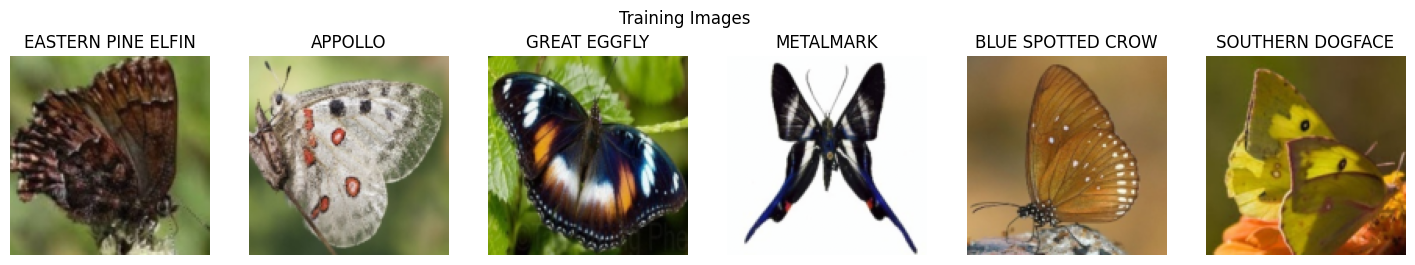

In [4]:
# Display some training images
plt.figure(figsize=(18,3))
plt.suptitle("Training Images")
for i,(image,label) in enumerate(train_dataloader):
    plt.subplot(1,6,i+1) 
    plt.axis("off")   
    plt.imshow((image[i]*std[:,None,None]+mean[:,None,None]).permute(1,2,0))
    plt.title(classes[label[i].item()])
    if i==5:
        break


In [5]:
#Hyperparameters
n_channels = 3
feature_vec = 512  
n_classes = len(classes)
n_epochs = 50 # Set the number of epochs for training the CNN classifier
class CNN_Classifier(nn.Module):
    def __init__(self):
        super(CNN_Classifier, self).__init__()
        self.main = nn.Sequential(
            #  128 x 128
            self.block(n_channels, feature_vec, 4,2,1), # 32 x 32
            self.block(feature_vec, feature_vec * 2, 4,2,1), # 8 x 8
            self.block(feature_vec * 2, feature_vec * 4, 4,2,1), # 2 x 2
            nn.Conv2d(feature_vec * 4, feature_vec * 8, 4, 2, 1),
            nn.BatchNorm2d(feature_vec * 8),
            nn.ReLU(),
        )
        self.fc = nn.Linear(feature_vec*8, n_classes)
        self.softmax = nn.Softmax(dim=1)

    def block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        x = self.main(x)
        x = x.view(x.size(0), -1)  # Flatten the output
        x = self.fc(x)
        return self.softmax(x)

def weight_initialization(m):
    classname = m.__class__.__name__
    if classname.find('Conv') !=-1 or classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data,0.0,0.02)


classifier = CNN_Classifier().to(device)
classifier.apply(weight_initialization)
optimizer = torch.optim.Adam(classifier.parameters(), lr=0.0002)
criterion = nn.CrossEntropyLoss()


In [9]:
best_val_accuracy = 0.0

progress = tqdm.tqdm(range(n_epochs), desc="Epochs", position=0)
for epoch in progress:
    running_loss = 0.0
    classifier.train()  # Set the model to training mode
    for i, (image, label) in enumerate(train_dataloader):
        image = image.to(device)
        label = label.to(device)
        optimizer.zero_grad()
        logits = classifier(image)
        loss = criterion(logits, label)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    progress.set_postfix({"Loss": running_loss / len(train_dataloader)})
    running_loss = 0.0  

    # Validation loop
    classifier.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for image, label in val_dataloader:
            image = image.to(device)
            label = label.to(device)
            logits = classifier(image)
            _, predicted = torch.max(logits.data, 1)
            total += label.size(0)
            correct += (predicted == label).sum().item()
    
    val_accuracy = correct / total

    # Save the best model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(classifier, "best_butterfly_classifier.pth")
        print("Best model saved with accuracy: {:.4f}".format(best_val_accuracy))

print("Training Completed")


Epochs:   2%|▎         | 1/40 [00:52<33:59, 52.30s/it, Loss=3.34]

Best model saved with accuracy: 0.7598


Epochs:   5%|▌         | 2/40 [01:40<31:26, 49.64s/it, Loss=3.34]

Best model saved with accuracy: 0.7639


Epochs:  25%|██▌       | 10/40 [07:59<23:58, 47.97s/it, Loss=3.34]

...

Best model saved with accuracy: 0.7669


Epochs:  40%|████      | 16/40 [12:49<19:19, 48.32s/it, Loss=3.34]

Best model saved with accuracy: 0.7690


Epochs: 100%|██████████| 40/40 [32:06<00:00, 48.16s/it, Loss=3.34]

Training Completed


In [13]:
# Load the best model
classifier = torch.load("best_butterfly_classifier.pth",weights_only=False)
classifier.eval()  # Set the model to evaluation mode

# Test the model
correct = 0
total = 0
with torch.no_grad():
    for image, label in test_dataloader:
        image = image.to(device)
        label = label.to(device)
        logits = classifier(image)
        _, predicted = torch.max(logits.data, 1)
        total += label.size(0)
        correct += (predicted == label).sum().item()
        
test_accuracy = correct / total
print("Test Accuracy: {:.4f}".format(test_accuracy))
#F 1 Score  
from sklearn.metrics import f1_score
y_true = []
y_pred = []
classifier.eval()

with torch.no_grad():
    for image, label in test_dataloader:
        image = image.to(device)
        label = label.to(device)
        logits = classifier(image)
        _, predicted = torch.max(logits.data, 1)
        y_true += label.cpu().numpy().tolist()
        y_pred += predicted.cpu().numpy().tolist()

f1 = f1_score(y_true, y_pred, average="weighted")
print("F1 Score: {:.4f}".format(f1))


Test Accuracy: 0.7428
F1 Score: 0.7463


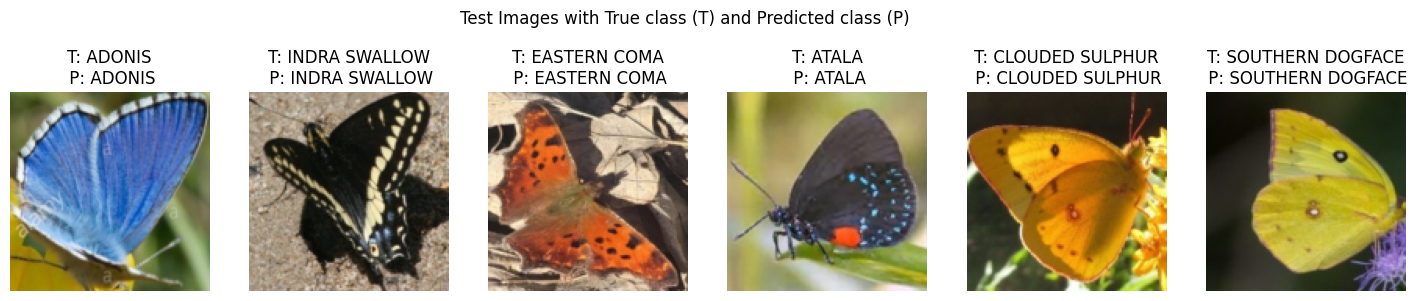

In [33]:
# Plot some images with true and predicted labels
plt.figure(figsize=(18, 3))
plt.suptitle("Test Images with True class (T) and Predicted class (P)",y = 1.1)
mean = mean.to('cpu')
std = std.to('cpu')
random_indices = random.sample(range(len(dataset)), 6)
for i, idx in enumerate(random_indices):
    image, label = dataset[idx]
    image = image.unsqueeze(0).to(device)
    logits = classifier(image)
    _, predicted = torch.max(logits.data, 1)
    plt.subplot(1, 6, i + 1)
    plt.axis("off")
    plt.imshow((image[0].to('cpu') * std[:, None, None] + mean[:, None, None]).permute(1, 2, 0))
    plt.title("T: {}\n P: {}".format(classes[label], classes[predicted.item()]))

plt.show()
